# SVM (Support Vector Machines)

Demonstração dos conceitos fundamentais de **SVM** utilizando dados linearmente separáveis e não lineares.

Tópicos abordados:
- Geração e visualização de datasets
- Kernel linear vs. RBF vs. Polinomial
- Visualização da fronteira de decisão e vetores de suporte
- Efeito do parâmetro de regularização **C**
- Comparação final dos modelos


In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn import svm
from sklearn.datasets import make_blobs, make_circles
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

## 1. Geração dos Datasets

Serão utilizados dois datasets:
- **Linearmente separável** (`make_blobs`): dois grupos bem definidos, que um hiperplano reto consegue separar.
- **Não linear** (`make_circles`): dois anéis concêntricos, impossíveis de separar com uma linha reta.


In [4]:
try:
    X_linear, y_linear = make_blobs(
        n_samples=200,
        centers=2,
        random_state=42,
        cluster_std=1.2
    )

    X_nonlinear, y_nonlinear = make_circles(
        n_samples=200,
        factor=0.5,
        noise=0.1,
        random_state=42
    )
    print("Datasets generated successfully.")
except Exception as e:
    print(f"Error generating datasets: {e}")
    exit(1)


Datasets generated successfully.


## 2. Visualização dos Datasets


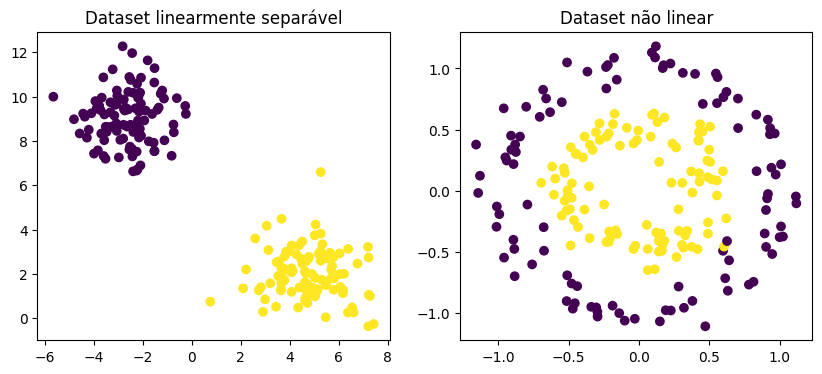

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))

ax[0].scatter(X_linear[:,0], X_linear[:,1], c=y_linear)
ax[0].set_title("Dataset linearmente separável")

ax[1].scatter(X_nonlinear[:,0], X_nonlinear[:,1], c=y_nonlinear)
ax[1].set_title("Dataset não linear")

plt.show()

## 3. Funções Auxiliares

- `plot_decision_boundary`: plota a fronteira de decisão do modelo, as margens (linhas tracejadas) e os **vetores de suporte** (círculos em vermelho).
- `train_and_evaluate`: treina um SVM com o kernel especificado e retorna o modelo e a acurácia no conjunto de teste.


In [6]:
def plot_decision_boundary(model, X, y, title):

    plt.figure(figsize=(5, 4))

    ax = plt.gca()

    xlim = (X[:, 0].min() - 1, X[:, 0].max() + 1)
    ylim = (X[:, 1].min() - 1, X[:, 1].max() + 1)

    xx = np.linspace(xlim[0], xlim[1], 100)
    yy = np.linspace(ylim[0], ylim[1], 100)

    YY, XX = np.meshgrid(yy, xx)

    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = model.decision_function(xy).reshape(XX.shape)

    # Fronteira de decisão (sólida) e margens (tracejadas)
    ax.contour(
        XX, YY, Z,
        levels=[-1, 0, 1],
        linestyles=['--', '-', '--'],
        colors='k'
    )

    ax.scatter(X[:, 0], X[:, 1], c=y, zorder=2)

    # Vetores de suporte
    sv = model.support_vectors_
    ax.scatter(
        sv[:, 0], sv[:, 1],
        s=120, linewidths=1.5,
        facecolors='none', edgecolors='red',
        zorder=3, label=f'Vetores de suporte ({len(sv)})'
    )

    ax.legend(fontsize=8)
    plt.title(title)
    plt.show()


In [7]:
def train_and_evaluate(X, y, kernel):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    model = svm.SVC(kernel=kernel)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    return model, acc

## 4. Kernel Linear — Dataset Separável

Com dados linearmente separáveis, o kernel linear encontra facilmente um hiperplano que divide as classes com alta acurácia.


Accuracy (linear dataset): 1.0


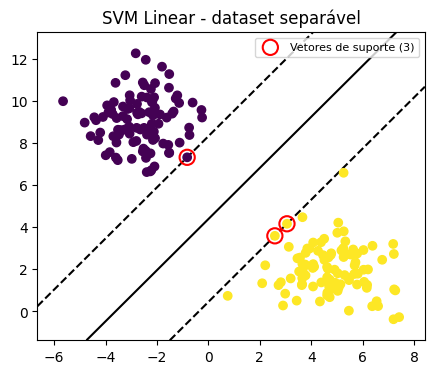

In [8]:
model_linear, acc_linear = train_and_evaluate(X_linear, y_linear, "linear")

print("Accuracy (linear dataset):", acc_linear)

plot_decision_boundary(
    model_linear,
    X_linear,
    y_linear,
    "SVM Linear - dataset separável"
)

## 5. Kernel Linear - Dataset Não Separável

Quando os dados não são linearmente separáveis, o kernel linear falha; a fronteira reta não consegue capturar a estrutura circular dos dados.


Accuracy (non-linear dataset): 0.4666666666666667


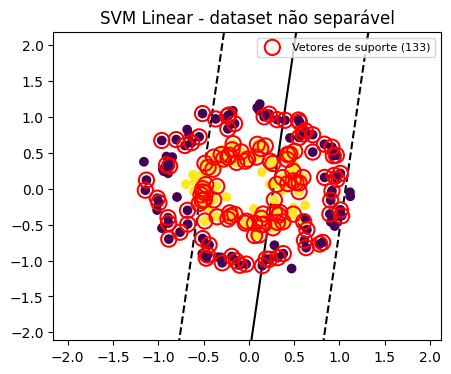

In [9]:
model_nonlinear, acc_nonlinear = train_and_evaluate(X_nonlinear, y_nonlinear, "linear")

print("Accuracy (non-linear dataset):", acc_nonlinear)

plot_decision_boundary(
    model_nonlinear,
    X_nonlinear,
    y_nonlinear,
    "SVM Linear - dataset não separável"
)

## 6. Kernel RBF - Dataset Não Separável

O kernel **RBF (Radial Basis Function)** projeta os dados em um espaço de dimensão maior, onde eles se tornam linearmente separáveis. Ideal para padrões circulares/não lineares.


Accuracy (RBF kernel): 0.9833333333333333


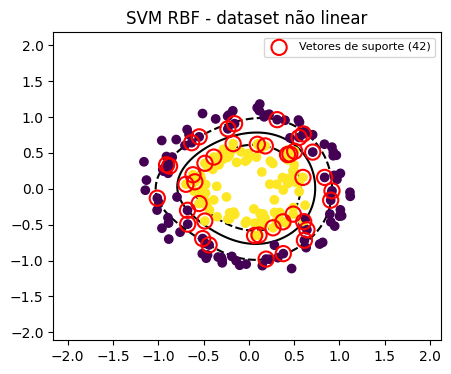

In [10]:
model_rbf, acc_rbf = train_and_evaluate(X_nonlinear, y_nonlinear, "rbf")

print("Accuracy (RBF kernel):", acc_rbf)

plot_decision_boundary(
    model_rbf,
    X_nonlinear,
    y_nonlinear,
    "SVM RBF - dataset não linear"
)

## 7. Kernel Polinomial - Dataset Não Separável

O kernel **polinomial** também projeta os dados em dimensões maiores. O parâmetro `degree` controla o grau do polinômio utilizado.


Accuracy (polynomial kernel): 0.5833333333333334


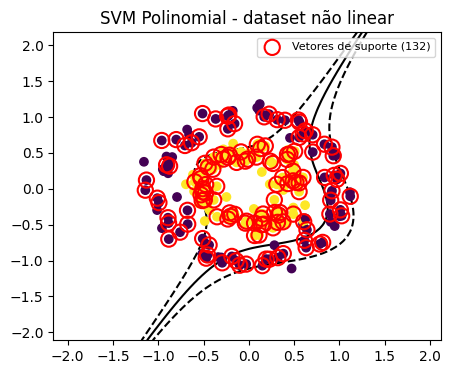

In [11]:
model_poly, acc_poly = train_and_evaluate(X_nonlinear, y_nonlinear, "poly")

print("Accuracy (polynomial kernel):", acc_poly)

plot_decision_boundary(
    model_poly,
    X_nonlinear,
    y_nonlinear,
    "SVM Polinomial - dataset não linear"
)


## 8. Efeito do Parâmetro C

O parâmetro **C** controla o trade-off entre maximizar a margem e minimizar os erros de classificação:
- **C baixo** → margem maior, mais erros tolerados (underfitting)
- **C alto** → margem menor, menos erros tolerados (overfitting)


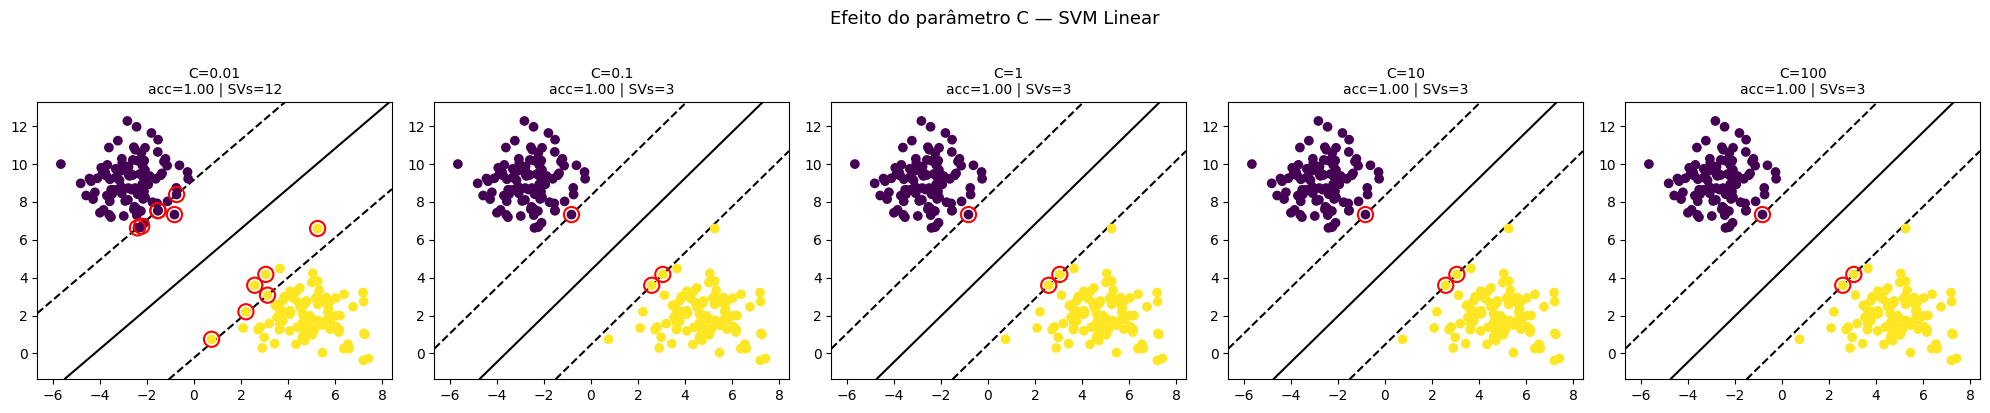

In [12]:
C_values = [0.01, 0.1, 1, 10, 100]

fig, axes = plt.subplots(1, len(C_values), figsize=(20, 4))

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_linear, y_linear, test_size=0.3, random_state=42
)

for ax, C in zip(axes, C_values):
    model_c = svm.SVC(kernel='linear', C=C)
    model_c.fit(X_train_c, y_train_c)
    acc_c = accuracy_score(y_test_c, model_c.predict(X_test_c))

    xlim = (X_linear[:, 0].min() - 1, X_linear[:, 0].max() + 1)
    ylim = (X_linear[:, 1].min() - 1, X_linear[:, 1].max() + 1)

    xx = np.linspace(xlim[0], xlim[1], 100)
    yy = np.linspace(ylim[0], ylim[1], 100)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = model_c.decision_function(xy).reshape(XX.shape)

    ax.contour(XX, YY, Z, levels=[-1, 0, 1], linestyles=['--', '-', '--'], colors='k')
    ax.scatter(X_linear[:, 0], X_linear[:, 1], c=y_linear, zorder=2)

    sv = model_c.support_vectors_
    ax.scatter(sv[:, 0], sv[:, 1], s=120, facecolors='none', edgecolors='red', linewidths=1.5, zorder=3)

    n_sv = len(sv)
    ax.set_title(f"C={C}\nacc={acc_c:.2f} | SVs={n_sv}", fontsize=10)

plt.suptitle("Efeito do parâmetro C — SVM Linear", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 9. Comparação Final dos Modelos

Resumo da acurácia de cada combinação kernel/dataset testada.


In [13]:
import pandas as pd

results = pd.DataFrame({
    "Modelo":  [
        "Linear (dataset separável)",
        "Linear (dataset não separável)",
        "RBF (dataset não separável)",
        "Polinomial (dataset não separável)",
    ],
    "Kernel":  ["linear", "linear", "rbf", "poly"],
    "Dataset": ["linear", "não linear", "não linear", "não linear"],
    "Acurácia": [acc_linear, acc_nonlinear, acc_rbf, acc_poly],
})

results["Acurácia"] = results["Acurácia"].map("{:.2%}".format)

print(results.to_string(index=False))


                            Modelo Kernel    Dataset Acurácia
        Linear (dataset separável) linear     linear  100.00%
    Linear (dataset não separável) linear não linear   46.67%
       RBF (dataset não separável)    rbf não linear   98.33%
Polinomial (dataset não separável)   poly não linear   58.33%
